/Users/kai/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/xd/6b7x17ts5b7612cqwyl3b63m0000gp/T/ipykernel_44303/2430553143.py:74: RuntimeWarning: invalid value encountered in scalar subtract
  tol_lambda = delta * np.sum(np.abs(lambda_k)) \


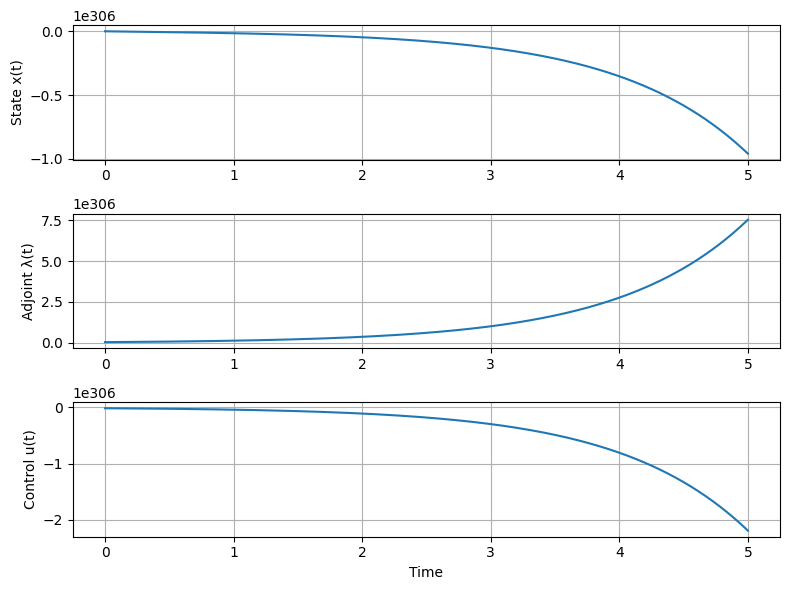

Final state x(T) = -9.581961926423963e+305


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
x0 = 1
xf = 2

T = 5
N = 1000

delta = 0.001

t = np.linspace(0, T, N + 1)
h = T / N

u_k = np.zeros(N + 1)
x_k = np.zeros(N + 1)
lambda_k = np.zeros(N + 1)

x_k[0] = x0

converged = -1

while converged < 0:

    u_old = u_k.copy()
    x_old = x_k.copy()
    lambda_old = lambda_k.copy()

    for i in range(N):

        k1 = u_k[i] - x_k[i]

        k2 = 0.5 * (u_k[i] + u_k[i+1]) \
             - (x_k[i] + 0.5 * h * k1)

        k3 = 0.5 * (u_k[i] + u_k[i+1]) \
             - (x_k[i] + 0.5 * h * k2)

        k4 = u_k[i+1] - (x_k[i] + h * k3)

        x_k[i+1] = x_k[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)


    error = xf - x_k[-1]

    lambda_k[-1] += error

    for i in range(N):

        j = N - i

        k1 = lambda_k[j]

        k2 = lambda_k[j] - 0.5 * h * k1

        k3 = lambda_k[j] - 0.5 * h * k2

        k4 = lambda_k[j] - h * k3

        lambda_k[j-1] = lambda_k[j] \
                        - (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    u_new = -lambda_k
    u_k = 0.05 * u_new + 0.95 * u_old


    tol_u = delta * np.sum(np.abs(u_k)) \
            - np.sum(np.abs(u_k - u_old))

    tol_x = delta * np.sum(np.abs(x_k)) \
            - np.sum(np.abs(x_k - x_old))

    tol_lambda = delta * np.sum(np.abs(lambda_k)) \
                 - np.sum(np.abs(lambda_k - lambda_old))

    converged = min(tol_u, tol_x, tol_lambda)

plt.figure(figsize=(8, 6))

plt.subplot(3, 1, 1)
plt.plot(t, x_k)
plt.ylabel('State x(t)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, lambda_k)
plt.ylabel('Adjoint λ(t)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_k)
plt.ylabel('Control u(t)')
plt.xlabel('Time')
plt.grid()

plt.tight_layout()
plt.show()

print("Final state x(T) =", x_k[-1])

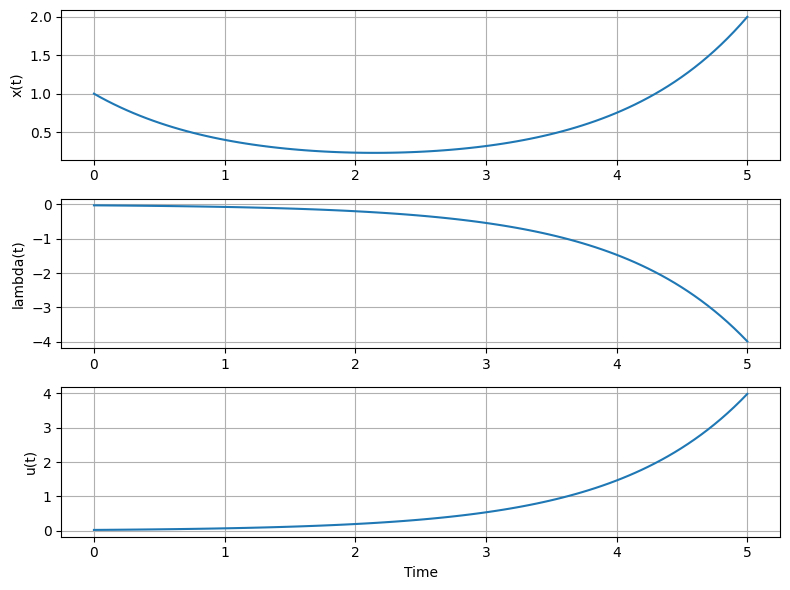

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

def ode(t, y):

    x = y[0]
    lam = y[1]

    u = -lam

    dxdt = u - x
    dlamdt = lam

    return np.vstack((dxdt, dlamdt))


def bc(ya, yb):

    return np.array([
        ya[0] - 1,
        yb[0] - 2
    ])


t = np.linspace(0, 5, 100)

y_guess = np.zeros((2, t.size))

sol = solve_bvp(ode, bc, t, y_guess)

x = sol.y[0]
lam = sol.y[1]
u = -lam

plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(sol.x, x)
plt.ylabel('x(t)')
plt.grid()

plt.subplot(3,1,2)
plt.plot(sol.x, lam)
plt.ylabel('lambda(t)')
plt.grid()

plt.subplot(3,1,3)
plt.plot(sol.x, u)
plt.ylabel('u(t)')
plt.xlabel('Time')
plt.grid()

plt.tight_layout()
plt.show()